<a href="https://colab.research.google.com/github/lilianabs/kaggle-tools/blob/main/Feat_eng_interaction_features_via_products.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

🧠 1. What is an interaction feature?

An interaction means:

“The effect of one feature depends on another.”

A product feature is the simplest form:

x = x1 * x2
interaction

🧠 Core intuition

Products help when:

One feature modulates another
Relationships are conditional
Effects are multiplicative rather than additive

📊 3. When to suspect interactions

✅ Case 1 — Weak individual features

If:

feature A weak
feature B weak

BUT together they define regions/classes.

✅ Case 2 — Nonlinear decision boundaries

Suppose:

High risk only when:
age is high
AND blood pressure is high

Interaction captures:

“joint effect”

✅ Case 3 — Domain logic suggests dependency

Examples:

price × quantity → revenue
height × weight → BMI-like effects
impressions × CTR → clicks
🔍 4. Visual clues for interactions

This is one of the most useful intuitions.

A. Scatter plots colored by target

sns.scatterplot(
    x=df["x1"],
    y=df["x2"],
    hue=df["target"]
)


What to look for

✅ Rectangular/quadrant separation

Example:

target=1 mostly in upper-right

This suggests:

interaction
nonlinear relationship


Tree-based models

Often learn interactions automatically.

Examples:

Random Forest
XGBoost

They create interaction-like splits naturally.

👉 So manual interaction engineering matters less.

In [7]:
import numpy as np
import pandas as pd
import seaborn as sns

np.random.seed(42)
n = 1000

x1 = np.random.normal(0, 1, n)
x2 = np.random.normal(0, 1, n)

# Interaction target
y = ((x1 * x2) > 0.5).astype(int)

df = pd.DataFrame({
    "x1": x1,
    "x2": x2,
    "target": y
})

In [2]:
df.head()

,x1,x2,target
0,0.496714,1.399355,1
1,-0.138264,0.924634,0
2,0.647689,0.059630,0
3,1.523030,-0.646937,0
4,-0.234153,0.698223,0


<Axes: xlabel='x1', ylabel='x2'>

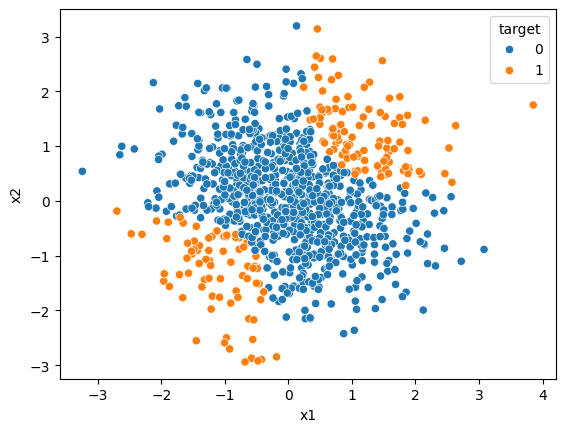

In [8]:
sns.scatterplot(
    x=df["x1"],
    y=df["x2"],
    hue=df["target"]
)

In [4]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

X = df[["x1", "x2"]]

model = LogisticRegression()
model.fit(X, df["target"])

preds = model.predict_proba(X)[:, 1]
roc_auc_score(df["target"], preds)

np.float64(0.5776686638544828)

In [5]:
df["x1_x2"] = df["x1"] * df["x2"]

X = df[["x1", "x2", "x1_x2"]]

model = LogisticRegression()
model.fit(X, df["target"])

preds = model.predict_proba(X)[:, 1]
roc_auc_score(df["target"], preds)

np.float64(0.9999462640049437)

🧠 7. How to systematically discover interactions

Method 1 — Domain knowledge (best)

Ask:

“Do these quantities combine meaningfully?”

Examples:

speed × time
price × quantity
dosage × duration

Method 2 — Residual analysis

If:

model consistently misses certain regions

Look for:

conditional relationships

Method 3 — Pairwise experimentation

For numerical features:

df["A_B"] = df["A"] * df["B"]

Test:

Does validation score improve?

Method 4 — SHAP interaction values (advanced)

Later-stage technique:

identifies interacting features automatically

Very useful in tree models.

⚠️ 8. Interaction explosion problem

If you have:

100 features

Possible pairwise products:


100×99/ 2 =4950

👉 Dangerous:

- overfitting
- computational cost
- noisy features

So:
- don’t brute force blindly

🎯 9. Practical heuristics

Create interaction candidates when:

✅ Both features individually show some signal
✅ Scatter plots show regions/clusters
✅ Domain knowledge suggests dependency
✅ Linear models underperform

Avoid when:
- features are pure noise
- tree models already perform well
- dataset is small